In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import joblib, os
from tqdm.auto import tqdm
import sys

import os
import pandas as pd
# from scapy.all import rdpcap, TCP, IP, Ether, Raw

# !pip install tabulate
from tabulate import tabulate # For pretty-printing tabular data in console

pd.set_option('display.max_columns', 500)
pd.set_option('display.max_rows', 500)


import time

# Import classifiers
from sklearn.ensemble import RandomForestClassifier

#import for preprocessing
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import StandardScaler,LabelEncoder, MinMaxScaler



# import methods for measuring accuracy, precision, recall etc
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    f1_score,
    confusion_matrix,
    classification_report
)
from sklearn.metrics import roc_curve, auc, roc_auc_score

In [ ]:
directory_path = '/content/drive/MyDrive/SytheticDataWatersDirectory'

#### We Save this File (my_data_dnp3_update_clean_data.csv) in this Notebook (https://colab.research.google.com/drive/1c5NQMB8xok7jipsLUOzy9preGvH9-d6D?usp=sharing)

In [ ]:
df = pd.read_csv(f"{directory_path}/my_data_dnp3_update_clean_data.csv")
print(f"Reloaded shape: {df.shape}")
df.head()

Reloaded shape: (1251549, 37)


,source_file,frame.number,frame.time_epoch,frame.time_relative,frame.time_delta,frame.len,frame.cap_len,eth.src,eth.dst,ip.src,ip.dst,ip.proto,ip.ttl,tcp.srcport,tcp.dstport,tcp.flags,tcp.len,tcp.window_size_value,tcp.checksum,tcp.time_delta,dnp3_present,dnp3.start,dnp3.len,dnp3.ctrl,dnp3.dst_addr,dnp3.src_addr,dnp3.dir,dnp3.prm,dnp3.fcb,dnp3.fcv,dnp3.func_code_link,dnp3.func_code,dnp3.func_name,dnp3.payload_len,dnp3.raw_hex,label,direction
0,20200515_DNP3_Cold_Restart_Attack_UOWM_DNP3_Da...,1,1.589556e+09,0.000000,NaN,84,84,be:0a:53:35:94:71,be:0a:53:15:bc:f6,192.168.1.1,192.168.1.5,6,64,41538,20001,24,18,312,24389,NaN,True,0x0564,11,196,13,2,1,1,0,0,4,1.0,READ,18,05640bc40d0002006db7cdcc013c0206505b,COLD_RESTART,request
1,20200515_DNP3_Cold_Restart_Attack_UOWM_DNP3_Da...,2,1.589556e+09,0.000756,0.000756,83,83,be:0a:53:15:bc:f6,be:0a:53:35:94:71,192.168.1.5,192.168.1.1,6,64,20001,41538,24,17,227,7867,0.000756,True,0x0564,10,68,2,13,0,1,0,0,4,129.0,RESPONSE,17,05640a4402000d004ea8d2cc810000062d,COLD_RESTART,response
2,20200515_DNP3_Cold_Restart_Attack_UOWM_DNP3_Da...,3,1.589556e+09,0.000836,0.000080,84,84,be:0a:53:35:94:71,be:0a:53:07:a6:60,192.168.1.1,192.168.1.9,6,64,51971,20001,24,18,312,49036,0.000080,True,0x0564,11,196,17,2,1,1,0,0,4,1.0,READ,18,05640bc4110002004e39cdcc013c0206505b,COLD_RESTART,request
3,20200515_DNP3_Cold_Restart_Attack_UOWM_DNP3_Da...,4,1.589556e+09,0.001856,0.001020,84,84,be:0a:53:35:94:71,be:0a:50:6c:87:fa,192.168.1.1,192.168.1.4,6,64,45297,20001,24,18,312,56407,0.001020,True,0x0564,11,196,12,2,1,1,0,0,4,1.0,READ,18,05640bc40c0002008575cdcc013c0206505b,COLD_RESTART,request
4,20200515_DNP3_Cold_Restart_Attack_UOWM_DNP3_Da...,5,1.589556e+09,0.002557,0.000701,83,83,be:0a:50:6c:87:fa,be:0a:53:35:94:71,192.168.1.4,192.168.1.1,6,64,20001,45297,24,17,227,561,0.000701,True,0x0564,10,68,2,12,0,1,0,0,4,129.0,RESPONSE,17,05640a4402000c000003d2cc810000062d,COLD_RESTART,response


In [ ]:
df.columns

Index(['source_file', 'frame.number', 'frame.time_epoch',
       'frame.time_relative', 'frame.time_delta', 'frame.len', 'frame.cap_len',
       'eth.src', 'eth.dst', 'ip.src', 'ip.dst', 'ip.proto', 'ip.ttl',
       'tcp.srcport', 'tcp.dstport', 'tcp.flags', 'tcp.len',
       'tcp.window_size_value', 'tcp.checksum', 'tcp.time_delta',
       'dnp3_present', 'dnp3.start', 'dnp3.len', 'dnp3.ctrl', 'dnp3.dst_addr',
       'dnp3.src_addr', 'dnp3.dir', 'dnp3.prm', 'dnp3.fcb', 'dnp3.fcv',
       'dnp3.func_code_link', 'dnp3.func_code', 'dnp3.func_name',
       'dnp3.payload_len', 'dnp3.raw_hex', 'label', 'direction'],
      dtype='object')

In [ ]:
df['label'].value_counts()

,count
label,
DISABLE_UNSOLICITED,382988
WARM_RESTART,382912
COLD_RESTART,382891
INIT_DATA,45245
STOP_APP,45242
REPLAY,4282
DNP3_ENUMERATE,3375
20200516_DNP3_Ιnfo,3342
MITM_DOS,1272


In [ ]:
label_mapping = {

    # Restart Attacks (same behavior)
    'COLD_RESTART': 'RESTART_ATTACK',
    'WARM_RESTART': 'RESTART_ATTACK',

    # DNP3 Reconnaissance (same behavior)
    'DNP3_ENUMERATE': 'DNP3_RECON',
    '20200516_DNP3_Ιnfo': 'DNP3_RECON',

    # DoS / Disruption Attacks
    'MITM_DOS': 'DOS_ATTACK',
    'ARP_POISONING': 'DOS_ATTACK',

    # Control / Manipulation Attacks
    'DISABLE_UNSOLICITED': 'CONTROL_ATTACK',
    'STOP_APP': 'CONTROL_ATTACK',
    'INIT_DATA': 'CONTROL_ATTACK',

    # Replay Attack (unique)
    'REPLAY': 'REPLAY_ATTACK',
}

df['label'] = df['label'].map(label_mapping)

print(df['label'].value_counts())

label
RESTART_ATTACK    765803
CONTROL_ATTACK    473475
DNP3_RECON          6717
REPLAY_ATTACK       4282
DOS_ATTACK          1272
Name: count, dtype: int64


In [ ]:
print(df['label'].value_counts(normalize=True))

label
RESTART_ATTACK    0.611884
CONTROL_ATTACK    0.378311
DNP3_RECON        0.005367
REPLAY_ATTACK     0.003421
DOS_ATTACK        0.001016
Name: proportion, dtype: float64


In [ ]:
df.columns

Index(['source_file', 'frame.number', 'frame.time_epoch',
       'frame.time_relative', 'frame.time_delta', 'frame.len', 'frame.cap_len',
       'eth.src', 'eth.dst', 'ip.src', 'ip.dst', 'ip.proto', 'ip.ttl',
       'tcp.srcport', 'tcp.dstport', 'tcp.flags', 'tcp.len',
       'tcp.window_size_value', 'tcp.checksum', 'tcp.time_delta',
       'dnp3_present', 'dnp3.start', 'dnp3.len', 'dnp3.ctrl', 'dnp3.dst_addr',
       'dnp3.src_addr', 'dnp3.dir', 'dnp3.prm', 'dnp3.fcb', 'dnp3.fcv',
       'dnp3.func_code_link', 'dnp3.func_code', 'dnp3.func_name',
       'dnp3.payload_len', 'dnp3.raw_hex', 'label', 'direction'],
      dtype='object')

In [ ]:
# Check if 20000 and 20003 exist in the dataframe at all
for port in [20000, 20001, 20002, 20003]:
    cnt = ((df["tcp.srcport"] == port) | (df["tcp.dstport"] == port)).sum()
    print(f"Port {port}: {cnt} packets")

Port 20000: 12271 packets
Port 20001: 413089 packets
Port 20002: 413134 packets
Port 20003: 413055 packets


In [ ]:
# Primary: use the dnp3_present flag (already parsed by your pipeline)
print("Packets with dnp3_present=True:", df["dnp3_present"].sum())

dnp3_df = df[df["dnp3_present"] == True].copy()
print(f"Filtered DNP3 packets (by dnp3_present): {len(dnp3_df)} / {len(df)} total packets")

Packets with dnp3_present=True: 1251549
Filtered DNP3 packets (by dnp3_present): 1251549 / 1251549 total packets


In [ ]:
# Cross-check: union with known DNP3 ports (20000, 20001, 20002)
dnp3_ports = {20000, 20001, 20002, 20003}
port_mask = df["tcp.srcport"].isin(dnp3_ports) | df["tcp.dstport"].isin(dnp3_ports)
flag_mask = df["dnp3_present"] == True

print("By port only:", port_mask.sum())
print("By flag only:", flag_mask.sum())
print("By port OR flag:", (port_mask | flag_mask).sum())
print("By port AND flag:", (port_mask & flag_mask).sum())
print("Port but NOT flagged:", (port_mask & ~flag_mask).sum())
print("Flagged but NOT in port range:", (flag_mask & ~port_mask).sum())

By port only: 1251549
By flag only: 1251549
By port OR flag: 1251549
By port AND flag: 1251549
Port but NOT flagged: 0
Flagged but NOT in port range: 0


In [ ]:
print("Total rows in df:", len(df))
print("dnp3_present True:", (df["dnp3_present"] == True).sum())
print("dnp3_present False:", (df["dnp3_present"] == False).sum())
print("Unique dnp3.func_name values:", df["dnp3.func_name"].unique())

Total rows in df: 1251549
dnp3_present True: 1251549
dnp3_present False: 0
Unique dnp3.func_name values: ['READ' 'RESPONSE' 'COLD_RESTART' 'CONFIRM' 'DIRECT_OPERATE'
 'UNSOLICITED_RESPONSE' 'WARM_RESTART' 'FREEZE_AT_TIME' 'UNKNOWN'
 'STOP_APPL' 'INITIALIZE_DATA' 'DISABLE_UNSOLICITED']


In [ ]:
df.head()

,source_file,frame.number,frame.time_epoch,frame.time_relative,frame.time_delta,frame.len,frame.cap_len,eth.src,eth.dst,ip.src,ip.dst,ip.proto,ip.ttl,tcp.srcport,tcp.dstport,tcp.flags,tcp.len,tcp.window_size_value,tcp.checksum,tcp.time_delta,dnp3_present,dnp3.start,dnp3.len,dnp3.ctrl,dnp3.dst_addr,dnp3.src_addr,dnp3.dir,dnp3.prm,dnp3.fcb,dnp3.fcv,dnp3.func_code_link,dnp3.func_code,dnp3.func_name,dnp3.payload_len,dnp3.raw_hex,label,direction
0,20200515_DNP3_Cold_Restart_Attack_UOWM_DNP3_Da...,1,1.589556e+09,0.000000,NaN,84,84,be:0a:53:35:94:71,be:0a:53:15:bc:f6,192.168.1.1,192.168.1.5,6,64,41538,20001,24,18,312,24389,NaN,True,0x0564,11,196,13,2,1,1,0,0,4,1.0,READ,18,05640bc40d0002006db7cdcc013c0206505b,RESTART_ATTACK,request
1,20200515_DNP3_Cold_Restart_Attack_UOWM_DNP3_Da...,2,1.589556e+09,0.000756,0.000756,83,83,be:0a:53:15:bc:f6,be:0a:53:35:94:71,192.168.1.5,192.168.1.1,6,64,20001,41538,24,17,227,7867,0.000756,True,0x0564,10,68,2,13,0,1,0,0,4,129.0,RESPONSE,17,05640a4402000d004ea8d2cc810000062d,RESTART_ATTACK,response
2,20200515_DNP3_Cold_Restart_Attack_UOWM_DNP3_Da...,3,1.589556e+09,0.000836,0.000080,84,84,be:0a:53:35:94:71,be:0a:53:07:a6:60,192.168.1.1,192.168.1.9,6,64,51971,20001,24,18,312,49036,0.000080,True,0x0564,11,196,17,2,1,1,0,0,4,1.0,READ,18,05640bc4110002004e39cdcc013c0206505b,RESTART_ATTACK,request
3,20200515_DNP3_Cold_Restart_Attack_UOWM_DNP3_Da...,4,1.589556e+09,0.001856,0.001020,84,84,be:0a:53:35:94:71,be:0a:50:6c:87:fa,192.168.1.1,192.168.1.4,6,64,45297,20001,24,18,312,56407,0.001020,True,0x0564,11,196,12,2,1,1,0,0,4,1.0,READ,18,05640bc40c0002008575cdcc013c0206505b,RESTART_ATTACK,request
4,20200515_DNP3_Cold_Restart_Attack_UOWM_DNP3_Da...,5,1.589556e+09,0.002557,0.000701,83,83,be:0a:50:6c:87:fa,be:0a:53:35:94:71,192.168.1.4,192.168.1.1,6,64,20001,45297,24,17,227,561,0.000701,True,0x0564,10,68,2,12,0,1,0,0,4,129.0,RESPONSE,17,05640a4402000c000003d2cc810000062d,RESTART_ATTACK,response


In [ ]:
df = df[df["dnp3.func_code"].notna()].copy()
print(f"Filtered to {len(df)} packets with valid DNP3 function codes")

Filtered to 1251549 packets with valid DNP3 function codes


In [ ]:
# Fill missing dnp3.fcb/fcv with -1 (indicating "Not Applicable")
df['dnp3.fcb'] = df['dnp3.fcb'].fillna(-1)
df['dnp3.fcv'] = df['dnp3.fcv'].fillna(-1)

# Fill missing payload_len with 0
df['dnp3.payload_len'] = df['dnp3.payload_len'].fillna(0)

In [ ]:
df.isnull().sum()

,0
source_file,0
frame.number,0
frame.time_epoch,0
frame.time_relative,0
frame.time_delta,1
frame.len,0
frame.cap_len,0
eth.src,0
eth.dst,0
ip.src,0


In [ ]:
def drop_irrelevent_features(df, columns):
  df = df.drop(columns, axis = 1)
  return df

In [ ]:
not_required_features = [
    "source_file",          # file identifier, not generalizable
    "frame.number",          # just a packet index
    "frame.time_epoch",      # absolute timestamp, not generalizable
    "eth.src",               # MAC address (identifier)
    "eth.dst",               # MAC address (identifier)
    "ip.src",                # IP address (identifier)
    "ip.dst",                # IP address (identifier)
    "tcp.checksum",          # validation checksum, no predictive value
    "dnp3.raw_hex",          # raw hex payload, too high-cardinality
    "direction"
]

df = drop_irrelevent_features(df, not_required_features)
df.shape

(1251549, 27)

In [ ]:
pd.set_option('display.max_columns', None)

In [ ]:
df.head()

,frame.time_relative,frame.time_delta,frame.len,frame.cap_len,ip.proto,ip.ttl,tcp.srcport,tcp.dstport,tcp.flags,tcp.len,tcp.window_size_value,tcp.time_delta,dnp3_present,dnp3.start,dnp3.len,dnp3.ctrl,dnp3.dst_addr,dnp3.src_addr,dnp3.dir,dnp3.prm,dnp3.fcb,dnp3.fcv,dnp3.func_code_link,dnp3.func_code,dnp3.func_name,dnp3.payload_len,label
0,0.000000,NaN,84,84,6,64,41538,20001,24,18,312,NaN,True,0x0564,11,196,13,2,1,1,0,0,4,1.0,READ,18,RESTART_ATTACK
1,0.000756,0.000756,83,83,6,64,20001,41538,24,17,227,0.000756,True,0x0564,10,68,2,13,0,1,0,0,4,129.0,RESPONSE,17,RESTART_ATTACK
2,0.000836,0.000080,84,84,6,64,51971,20001,24,18,312,0.000080,True,0x0564,11,196,17,2,1,1,0,0,4,1.0,READ,18,RESTART_ATTACK
3,0.001856,0.001020,84,84,6,64,45297,20001,24,18,312,0.001020,True,0x0564,11,196,12,2,1,1,0,0,4,1.0,READ,18,RESTART_ATTACK
4,0.002557,0.000701,83,83,6,64,20001,45297,24,17,227,0.000701,True,0x0564,10,68,2,12,0,1,0,0,4,129.0,RESPONSE,17,RESTART_ATTACK


In [ ]:
df.isnull().sum()

,0
frame.time_relative,0
frame.time_delta,1
frame.len,0
frame.cap_len,0
ip.proto,0
ip.ttl,0
tcp.srcport,0
tcp.dstport,0
tcp.flags,0
tcp.len,0


In [ ]:
# df['frame.time_delta'] = df['frame.time_delta'].fillna(0)
# df['tcp.time_delta'] = df['tcp.time_delta'].fillna(0)

df = df.dropna()

print(df.isnull().sum().sum(), "missing values remaining")

0 missing values remaining


In [ ]:
def column_statistics(df):
    """
    This function calculates and displays statistics for each column in a DataFrame.

    It checks for:
    - Number of unique values
    - Percentage of missing values
    - Percentage of the most frequent category
    - Data type of each column

    Parameters:
    df (pd.DataFrame): The DataFrame to analyze.

    Returns:
    pd.DataFrame: A DataFrame containing the statistics for each column.
    """
    stats = []

    for col in df.columns:
        unique_values = df[col].nunique()
        missing_percentage = df[col].isnull().sum() * 100 / df.shape[0]
        high_one_cat_percentage = df[col].value_counts(normalize=True, dropna=False).values[0] * 100
        dtype = df[col].dtype

        stats.append((col, unique_values, missing_percentage, high_one_cat_percentage, dtype))

    stats_df = pd.DataFrame(stats, columns=['Feature', 'Unique_values', '% MissingValues', '% High One Categorical Values', 'Type'])
    stats_df = stats_df.sort_values('% MissingValues', ascending=False).reset_index(drop=True)

    print(tabulate(stats_df, headers='keys', tablefmt='psql'))

    return stats_df

In [ ]:
stats_df = column_statistics(df)

+----+-----------------------+-----------------+-------------------+---------------------------------+---------+
|    | Feature               |   Unique_values |   % MissingValues |   % High One Categorical Values | Type    |
|----+-----------------------+-----------------+-------------------+---------------------------------+---------|
|  0 | frame.time_relative   |         1250968 |                 0 |                      0.00207743 | float64 |
|  1 | frame.time_delta      |          201484 |                 0 |                      0.547242   | float64 |
|  2 | frame.len             |              51 |                 0 |                     47.6953     | int64   |
|  3 | frame.cap_len         |              51 |                 0 |                     47.6953     | int64   |
|  4 | ip.proto              |               1 |                 0 |                    100          | int64   |
|  5 | ip.ttl                |               1 |                 0 |                    100     

In [ ]:
def drop_high_categrocal_features(df):
  # lets remove the features which has only one category value equal to 100% and missing value >=95%
  # because that are not good for model prediction
  stats = []
  for col in df.columns[:-1]:
      stats.append((col, df[col].nunique(), df[col].isnull().sum() * 100 / df.shape[0], df[col].value_counts(normalize=True, dropna=False).values[0] * 100, df[col].dtype))
  stats_df = pd.DataFrame(stats, columns=['Feature', 'Unique_values', '% MissingValues', '% highOneCategoricalValues', 'type'])
  df_ = stats_df.sort_values('% MissingValues', ascending=False)
  one_category_value = df_[(df_['% highOneCategoricalValues']==100) | (df_['% MissingValues']>=95)]
  print(tabulate(one_category_value, headers = 'keys', tablefmt = 'psql'))
  return one_category_value

In [ ]:
one_category_value = drop_high_categrocal_features(df)

+----+--------------+-----------------+-------------------+------------------------------+--------+
|    | Feature      |   Unique_values |   % MissingValues |   % highOneCategoricalValues | type   |
|----+--------------+-----------------+-------------------+------------------------------+--------|
|  4 | ip.proto     |               1 |                 0 |                          100 | int64  |
|  5 | ip.ttl       |               1 |                 0 |                          100 | int64  |
|  8 | tcp.flags    |               1 |                 0 |                          100 | int64  |
| 12 | dnp3_present |               1 |                 0 |                          100 | bool   |
| 13 | dnp3.start   |               1 |                 0 |                          100 | object |
| 20 | dnp3.fcb     |               1 |                 0 |                          100 | int64  |
| 21 | dnp3.fcv     |               1 |                 0 |                          100 | int64  |


In [ ]:
drop_features = one_category_value['Feature'].tolist()
drop_features

['ip.proto',
 'ip.ttl',
 'tcp.flags',
 'dnp3_present',
 'dnp3.start',
 'dnp3.fcb',
 'dnp3.fcv']

In [ ]:
# lets drop the features
df = df.drop(drop_features, axis=1)

In [ ]:
df.head()

,frame.time_relative,frame.time_delta,frame.len,frame.cap_len,tcp.srcport,tcp.dstport,tcp.len,tcp.window_size_value,tcp.time_delta,dnp3.len,dnp3.ctrl,dnp3.dst_addr,dnp3.src_addr,dnp3.dir,dnp3.prm,dnp3.func_code_link,dnp3.func_code,dnp3.func_name,dnp3.payload_len,label
1,0.000756,0.000756,83,83,20001,41538,17,227,0.000756,10,68,2,13,0,1,4,129.0,RESPONSE,17,RESTART_ATTACK
2,0.000836,0.000080,84,84,51971,20001,18,312,0.000080,11,196,17,2,1,1,4,1.0,READ,18,RESTART_ATTACK
3,0.001856,0.001020,84,84,45297,20001,18,312,0.001020,11,196,12,2,1,1,4,1.0,READ,18,RESTART_ATTACK
4,0.002557,0.000701,83,83,20001,45297,17,227,0.000701,10,68,2,12,0,1,4,129.0,RESPONSE,17,RESTART_ATTACK
5,0.002783,0.000226,84,84,40709,20001,18,312,0.000226,11,196,11,2,1,1,4,1.0,READ,18,RESTART_ATTACK


In [ ]:
df['label'].value_counts()

,count
label,
RESTART_ATTACK,765802
CONTROL_ATTACK,473475
DNP3_RECON,6717
REPLAY_ATTACK,4282
DOS_ATTACK,1272


In [ ]:
mapping = {
    "RESTART_ATTACK": 0,
    "CONTROL_ATTACK": 1,
    "DNP3_RECON": 2,
    "REPLAY_ATTACK": 3,
    "DOS_ATTACK": 4,
}

df["label_encoded"] = df["label"].map(mapping)

In [ ]:
df['dnp3.func_name'].value_counts()

,count
dnp3.func_name,
RESPONSE,612645
READ,580729
CONFIRM,18924
DISABLE_UNSOLICITED,10136
COLD_RESTART,10104
WARM_RESTART,10104
UNSOLICITED_RESPONSE,3361
DIRECT_OPERATE,3356
INITIALIZE_DATA,1117


In [ ]:
df.head()

,frame.time_relative,frame.time_delta,frame.len,frame.cap_len,tcp.srcport,tcp.dstport,tcp.len,tcp.window_size_value,tcp.time_delta,dnp3.len,dnp3.ctrl,dnp3.dst_addr,dnp3.src_addr,dnp3.dir,dnp3.prm,dnp3.func_code_link,dnp3.func_code,dnp3.func_name,dnp3.payload_len,label,label_encoded
1,0.000756,0.000756,83,83,20001,41538,17,227,0.000756,10,68,2,13,0,1,4,129.0,RESPONSE,17,RESTART_ATTACK,0
2,0.000836,0.000080,84,84,51971,20001,18,312,0.000080,11,196,17,2,1,1,4,1.0,READ,18,RESTART_ATTACK,0
3,0.001856,0.001020,84,84,45297,20001,18,312,0.001020,11,196,12,2,1,1,4,1.0,READ,18,RESTART_ATTACK,0
4,0.002557,0.000701,83,83,20001,45297,17,227,0.000701,10,68,2,12,0,1,4,129.0,RESPONSE,17,RESTART_ATTACK,0
5,0.002783,0.000226,84,84,40709,20001,18,312,0.000226,11,196,11,2,1,1,4,1.0,READ,18,RESTART_ATTACK,0


In [ ]:
df = df.drop(["label","dnp3.func_name"], axis=1)
df.shape

(1251548, 19)

In [ ]:
df = df.reset_index(drop=True)
df.head()

,frame.time_relative,frame.time_delta,frame.len,frame.cap_len,tcp.srcport,tcp.dstport,tcp.len,tcp.window_size_value,tcp.time_delta,dnp3.len,dnp3.ctrl,dnp3.dst_addr,dnp3.src_addr,dnp3.dir,dnp3.prm,dnp3.func_code_link,dnp3.func_code,dnp3.payload_len,label_encoded
0,0.000756,0.000756,83,83,20001,41538,17,227,0.000756,10,68,2,13,0,1,4,129.0,17,0
1,0.000836,0.000080,84,84,51971,20001,18,312,0.000080,11,196,17,2,1,1,4,1.0,18,0
2,0.001856,0.001020,84,84,45297,20001,18,312,0.001020,11,196,12,2,1,1,4,1.0,18,0
3,0.002557,0.000701,83,83,20001,45297,17,227,0.000701,10,68,2,12,0,1,4,129.0,17,0
4,0.002783,0.000226,84,84,40709,20001,18,312,0.000226,11,196,11,2,1,1,4,1.0,18,0


In [ ]:
# Either remove frame.time_delta or tcp.time_delta (they look redundant)
df = df.drop(["frame.time_delta"], axis=1)

In [ ]:
df.to_csv(f"{directory_path}/my_data_dnp3_update_clean_data_1.csv")

### Loading Clean Data

In [ ]:
import pandas as pd
df = pd.read_csv(f"{directory_path}/my_data_dnp3_update_clean_data_1.csv")
df = df.drop(["Unnamed: 0"], axis=1)
df.head()

,frame.time_relative,frame.len,frame.cap_len,tcp.srcport,tcp.dstport,tcp.len,tcp.window_size_value,tcp.time_delta,dnp3.len,dnp3.ctrl,dnp3.dst_addr,dnp3.src_addr,dnp3.dir,dnp3.prm,dnp3.func_code_link,dnp3.func_code,dnp3.payload_len,label_encoded
0,0.000756,83,83,20001,41538,17,227,0.000756,10,68,2,13,0,1,4,129.0,17,0
1,0.000836,84,84,51971,20001,18,312,0.000080,11,196,17,2,1,1,4,1.0,18,0
2,0.001856,84,84,45297,20001,18,312,0.001020,11,196,12,2,1,1,4,1.0,18,0
3,0.002557,83,83,20001,45297,17,227,0.000701,10,68,2,12,0,1,4,129.0,17,0
4,0.002783,84,84,40709,20001,18,312,0.000226,11,196,11,2,1,1,4,1.0,18,0


In [ ]:
CLASSES = ["RESTART_ATTACK", "CONTROL_ATTACK", "DNP3_RECON", "REPLAY_ATTACK", "DOS_ATTACK"]

In [ ]:
TOTAL_LABELS = len(CLASSES)
TOTAL_LABELS

5

In [ ]:
df.head()

,frame.time_relative,frame.len,frame.cap_len,tcp.srcport,tcp.dstport,tcp.len,tcp.window_size_value,tcp.time_delta,dnp3.len,dnp3.ctrl,dnp3.dst_addr,dnp3.src_addr,dnp3.dir,dnp3.prm,dnp3.func_code_link,dnp3.func_code,dnp3.payload_len,label_encoded
0,0.000756,83,83,20001,41538,17,227,0.000756,10,68,2,13,0,1,4,129.0,17,0
1,0.000836,84,84,51971,20001,18,312,0.000080,11,196,17,2,1,1,4,1.0,18,0
2,0.001856,84,84,45297,20001,18,312,0.001020,11,196,12,2,1,1,4,1.0,18,0
3,0.002557,83,83,20001,45297,17,227,0.000701,10,68,2,12,0,1,4,129.0,17,0
4,0.002783,84,84,40709,20001,18,312,0.000226,11,196,11,2,1,1,4,1.0,18,0


In [ ]:
df = df.rename(columns={"label_encoded": "Label_Grouped"})

In [ ]:
# lets extract the dependent and independent features
X = df.drop(['Label_Grouped'], axis=1)
y = df['Label_Grouped']

In [ ]:
# lets split the dataset stratified
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0, stratify=y)

In [ ]:
'''
Feature scaling marks the end of the data preprocessing in Machine Learning. It is a method to standardize the independent variables of a dataset within a specific range.
In other words, feature scaling limits the range of variables so that you can compare them on common grounds.

'''

min_max_scaler = StandardScaler()

X_train_std = min_max_scaler.fit_transform(X_train)
X_test_std = min_max_scaler.transform(X_test)

# SHAP (Features Selection)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:56:14] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


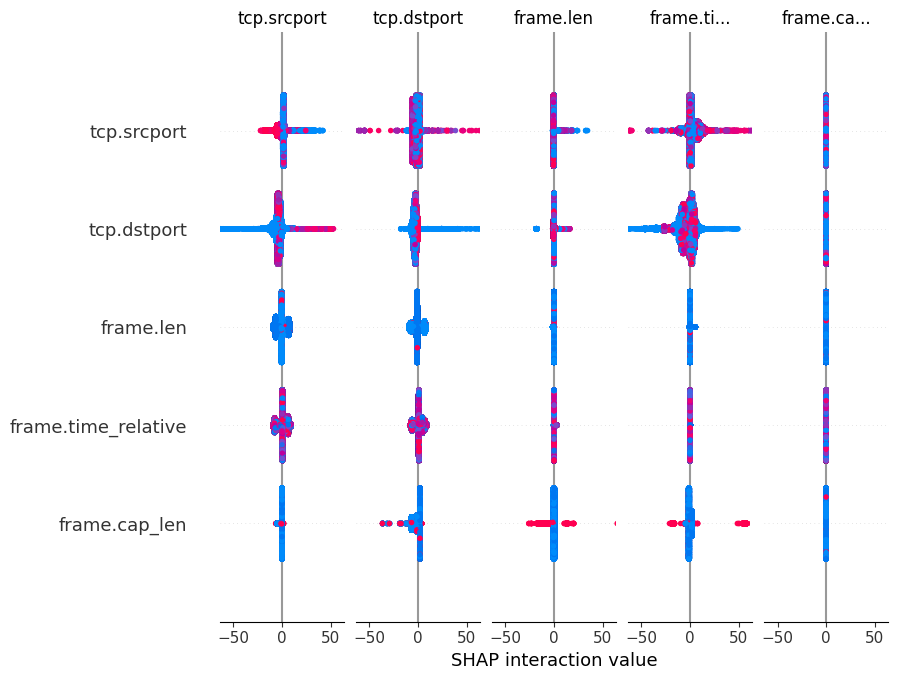

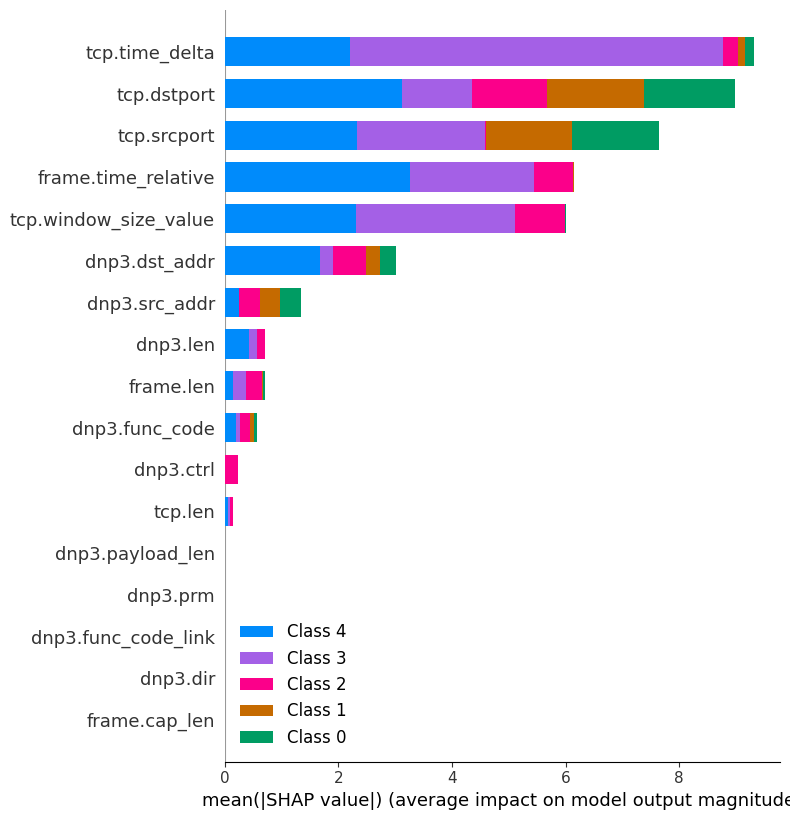

In [ ]:
import shap
import xgboost as xgb

# Train XGBoost
model = xgb.XGBClassifier(
    n_estimators=100,
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
)
model.fit(X_train_std, y_train)

# SHAP values
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_std)

# Summary plot — global feature importance
shap.summary_plot(shap_values, X_test_std, feature_names=X_train.columns)

# Bar plot — mean absolute SHAP values
shap.summary_plot(shap_values, X_test_std,
                  feature_names=X_train.columns,
                  plot_type='bar')

In [ ]:
X_train.columns

Index(['frame.time_relative', 'frame.len', 'frame.cap_len', 'tcp.srcport',
       'tcp.dstport', 'tcp.len', 'tcp.window_size_value', 'tcp.time_delta',
       'dnp3.len', 'dnp3.ctrl', 'dnp3.dst_addr', 'dnp3.src_addr', 'dnp3.dir',
       'dnp3.prm', 'dnp3.func_code_link', 'dnp3.func_code',
       'dnp3.payload_len'],
      dtype='object')

In [ ]:

# Check shape
print(f"SHAP values type: {type(shap_values)}")
print(f"SHAP values shape: {np.array(shap_values).shape}")

# Handle 3D array (samples, features, classes)
if isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    # Mean over samples and classes
    shap_mean = np.abs(shap_values).mean(axis=(0, 2))  # → (features,)

elif isinstance(shap_values, list):
    # List of 2D arrays, one per class
    shap_mean = np.mean([np.abs(sv).mean(axis=0) for sv in shap_values], axis=0)

else:
    # Binary / single output
    shap_mean = np.abs(shap_values).mean(axis=0)

print(f"shap_mean shape: {shap_mean.shape}")  # should be (n_features,)

# Build DataFrame
shap_df = pd.DataFrame({
    'feature'         : X_train.columns,
    'shap_importance' : shap_mean
})

shap_df['shap_importance_normalized'] = (
    shap_df['shap_importance'] / shap_df['shap_importance'].sum()
)

shap_df = shap_df.sort_values('shap_importance', ascending=False).reset_index(drop=True)
shap_df.index += 1
shap_df.index.name = 'rank'

print(shap_df.round(6))

SHAP values type: <class 'numpy.ndarray'>
SHAP values shape: (250310, 17, 5)
shap_mean shape: (17,)
                    feature  shap_importance  shap_importance_normalized
rank                                                                    
1            tcp.time_delta         1.862204                    0.207797
2               tcp.dstport         1.796771                    0.200496
3               tcp.srcport         1.529330                    0.170653
4       frame.time_relative         1.230156                    0.137269
5     tcp.window_size_value         1.200005                    0.133905
6             dnp3.dst_addr         0.603348                    0.067326
7             dnp3.src_addr         0.266439                    0.029731
8                  dnp3.len         0.143054                    0.015963
9                 frame.len         0.140624                    0.015692
10           dnp3.func_code         0.113195                    0.012631
11                dnp3.c

In [ ]:
# Drop zero SHAP features and port leakage features
exclude = [
    'tcp.srcport',       # leakage
    'tcp.dstport',       # leakage
    'frame.cap_len',     # zero SHAP
    'dnp3.dir',          # zero SHAP
    'dnp3.prm',          # zero SHAP
    'dnp3.func_code_link',# zero SHAP
    'dnp3.payload_len',  # zero SHAP
]

selected_features = shap_df[
    ~shap_df['feature'].isin(exclude)
]['feature'].tolist()

print(f"Selected {len(selected_features)} features:")
for i, f in enumerate(selected_features, 1):
    print(f"  {i:2}. {f}")

Selected 10 features:
   1. tcp.time_delta
   2. frame.time_relative
   3. tcp.window_size_value
   4. dnp3.dst_addr
   5. dnp3.src_addr
   6. dnp3.len
   7. frame.len
   8. dnp3.func_code
   9. dnp3.ctrl
  10. tcp.len


In [ ]:
import pickle

with open(f"{directory_path}/dnp3_scaler_for_SL.pkl", "wb") as f:
    pickle.dump(min_max_scaler, f)

In [ ]:
X_train.shape

(1001238, 17)

In [ ]:
X_train.columns

Index(['frame.time_relative', 'frame.len', 'frame.cap_len', 'tcp.srcport',
       'tcp.dstport', 'tcp.len', 'tcp.window_size_value', 'tcp.time_delta',
       'dnp3.len', 'dnp3.ctrl', 'dnp3.dst_addr', 'dnp3.src_addr', 'dnp3.dir',
       'dnp3.prm', 'dnp3.func_code_link', 'dnp3.func_code',
       'dnp3.payload_len'],
      dtype='object')

In [ ]:
X_train_std = pd.DataFrame(X_train_std, columns = X_train.columns)
X_test_std = pd.DataFrame(X_test_std, columns = X_train.columns)

In [ ]:
top_k_features = selected_features
top_k_features

['tcp.time_delta',
 'frame.time_relative',
 'tcp.window_size_value',
 'dnp3.dst_addr',
 'dnp3.src_addr',
 'dnp3.len',
 'frame.len',
 'dnp3.func_code',
 'dnp3.ctrl',
 'tcp.len']

In [ ]:
X_train_rf_std = X_train_std[top_k_features]
X_test_rf_std = X_test_std[top_k_features]

In [ ]:
X_train_rf_std.head()

,tcp.time_delta,frame.time_relative,tcp.window_size_value,dnp3.dst_addr,dnp3.src_addr,dnp3.len,frame.len,dnp3.func_code,dnp3.ctrl,tcp.len
0,0.124413,0.035260,1.205609,0.923966,-0.965073,-0.160965,-0.140360,-0.995816,1.014355,-0.140354
1,-0.090972,-1.415404,-0.919550,-0.762804,0.722750,-0.189701,-0.155909,1.014836,-0.985418,-0.155903
2,0.499833,-0.976245,0.692218,0.417935,-1.133855,-0.160965,-0.140360,-0.995816,1.014355,-0.140354
3,-0.085523,1.493520,1.205609,1.092643,-0.796291,-0.160965,-0.140360,-0.995816,1.014355,-0.140354
4,-0.090811,-1.325500,-0.919550,-0.762804,0.385186,-0.189701,-0.155909,1.014836,-0.985418,-0.155903


In [ ]:
X_train_rf_std.to_csv(f"{directory_path}/X_train_rf_std.csv", index=False)
X_test_rf_std.to_csv(f"{directory_path}/X_test_rf_std.csv", index=False)
y_train.to_csv(f"{directory_path}/y_train.csv", index=False)
y_test.to_csv(f"{directory_path}/y_test.csv", index=False)

#### Loading the Data

In [ ]:
import pandas as pd
X_train_rf_std = pd.read_csv(f"{directory_path}/X_train_rf_std.csv")
X_test_rf_std = pd.read_csv(f"{directory_path}/X_test_rf_std.csv")
y_train = pd.read_csv(f"{directory_path}/y_train.csv")
y_test = pd.read_csv(f"{directory_path}/y_test.csv")

In [ ]:
print("Training Dist.")
print(y_train.value_counts(normalize=True))
print("Testing Dist.")
print(y_test.value_counts(normalize=True))

Training Dist.
Label_Grouped
0                0.611883
1                0.378312
2                0.005366
3                0.003422
4                0.001017
Name: proportion, dtype: float64
Testing Dist.
Label_Grouped
0                0.611885
1                0.378311
2                0.005369
3                0.003420
4                0.001015
Name: proportion, dtype: float64


In [ ]:
X_train_rf_std.shape,X_train_rf_std.columns

((1001238, 10),
 Index(['tcp.time_delta', 'frame.time_relative', 'tcp.window_size_value',
        'dnp3.dst_addr', 'dnp3.src_addr', 'dnp3.len', 'frame.len',
        'dnp3.func_code', 'dnp3.ctrl', 'tcp.len'],
       dtype='object'))

In [ ]:
# At the top of your notebook — fixes ALL random operations globally
import numpy as np
import random

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# For sklearn
import os
os.environ['PYTHONHASHSEED'] = str(SEED)

In [ ]:
import pandas as pd
import numpy as np
import random
import os
from sklearn.utils import resample

# ── 0. Global seed for full reproducibility ──────────────────────────────────
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

# ── 1. Load data ─────────────────────────────────────────────────────────────
X_train_rf_std = pd.read_csv(f"{directory_path}/X_train_rf_std.csv")
X_test_rf_std  = pd.read_csv(f"{directory_path}/X_test_rf_std.csv")
y_train        = pd.read_csv(f"{directory_path}/y_train.csv")
y_test         = pd.read_csv(f"{directory_path}/y_test.csv")

print(f"Loaded shapes:")
print(f"X_train: {X_train_rf_std.shape}, y_train: {y_train.shape}")
print(f"X_test:  {X_test_rf_std.shape},  y_test:  {y_test.shape}")

# ── 2. Combine X and y for sampling ─────────────────────────────────────────
train_df = X_train_rf_std.copy()
train_df['Label_Grouped'] = y_train.values

test_df = X_test_rf_std.copy()
test_df['Label_Grouped'] = y_test.values

# ── 3. Target sizes ──────────────────────────────────────────────────────────
TRAIN_TARGET = 120_000
TEST_TARGET  = 30_000  # 80/20 split

train_dist = y_train['Label_Grouped'].value_counts(normalize=True).sort_index()
test_dist  = y_test['Label_Grouped'].value_counts(normalize=True).sort_index()

train_counts = (train_dist * TRAIN_TARGET).round().astype(int)
test_counts  = (test_dist  * TEST_TARGET).round().astype(int)

print("\nTarget train samples per class:")
print(train_counts)
print("\nTarget test samples per class:")
print(test_counts)

# ── 4. Stratified sampling function (fully deterministic) ────────────────────
def stratified_sample(df, target_counts, label_col='Label_Grouped', seed=42):
    sampled = []
    for label in sorted(target_counts.index):  # sorted → same order every time
        count   = target_counts[label]
        subset  = df[df[label_col] == label].sort_index()  # sort before sampling
        replace = len(subset) < count
        sampled.append(
            resample(subset, n_samples=count, replace=replace, random_state=seed)
        )
    return (
        pd.concat(sampled)
        .sample(frac=1, random_state=seed)
        .reset_index(drop=True)
    )

# ── 5. Sample ────────────────────────────────────────────────────────────────
train_sampled = stratified_sample(train_df, train_counts, seed=SEED)
test_sampled  = stratified_sample(test_df,  test_counts,  seed=SEED)

# ── 6. Split back into X and y ───────────────────────────────────────────────
X_train_sampled = train_sampled.drop(columns=['Label_Grouped'])
y_train_sampled = train_sampled['Label_Grouped'].reset_index(drop=True)

X_test_sampled  = test_sampled.drop(columns=['Label_Grouped'])
y_test_sampled  = test_sampled['Label_Grouped'].reset_index(drop=True)

# ── 7. Verify distribution ───────────────────────────────────────────────────
print("\n── Distribution Check ──────────────────────────────────────────────")
dist_check = pd.DataFrame({
    'original_train' : y_train['Label_Grouped'].value_counts(normalize=True).sort_index(),
    'sampled_train'  : y_train_sampled.value_counts(normalize=True).sort_index(),
    'original_test'  : y_test['Label_Grouped'].value_counts(normalize=True).sort_index(),
    'sampled_test'   : y_test_sampled.value_counts(normalize=True).sort_index(),
}).round(6)
print(dist_check)

# ── 8. Verify reproducibility ────────────────────────────────────────────────
print("\n── Reproducibility Check (first 3 rows) ────────────────────────────")
print(X_train_sampled.head(3))
print(y_train_sampled.head(3))

# ── 9. Final shapes ──────────────────────────────────────────────────────────
print(f"\n── Final Shapes ────────────────────────────────────────────────────")
print(f"X_train_sampled: {X_train_sampled.shape}")
print(f"y_train_sampled: {y_train_sampled.shape}")
print(f"X_test_sampled:  {X_test_sampled.shape}")
print(f"y_test_sampled:  {y_test_sampled.shape}")

Loaded shapes:
X_train: (1001238, 10), y_train: (1001238, 1)
X_test:  (250310, 10),  y_test:  (250310, 1)

Target train samples per class:
Label_Grouped
0    73426
1    45397
2      644
3      411
4      122
Name: proportion, dtype: int64

Target test samples per class:
Label_Grouped
0    18357
1    11349
2      161
3      103
4       30
Name: proportion, dtype: int64

── Distribution Check ──────────────────────────────────────────────
               original_train  sampled_train  original_test  sampled_test
Label_Grouped                                                            
0                    0.611883       0.611883       0.611885      0.611900
1                    0.378312       0.378308       0.378311      0.378300
2                    0.005366       0.005367       0.005369      0.005367
3                    0.003422       0.003425       0.003420      0.003433
4                    0.001017       0.001017       0.001015      0.001000

── Reproducibility Check (first 3 rows) 

In [ ]:
X_train_rf_std = X_train_sampled
X_test_rf_std = X_test_sampled
y_train = y_train_sampled
y_test = y_test_sampled

In [ ]:
X_train_rf_std.shape, X_test_rf_std.shape, y_train.shape, y_test.shape

((120000, 10), (30000, 10), (120000,), (30000,))

In [ ]:
y_test.value_counts(normalize=True)

,proportion
Label_Grouped,
0,0.611900
1,0.378300
2,0.005367
3,0.003433
4,0.001000


### **Model Building**

In [ ]:
import time

# Import classifiers
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier

#import for preprocessing
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import StandardScaler,LabelEncoder, MinMaxScaler
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay


# import methods for measuring accuracy, precision, recall etc
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    f1_score,
    confusion_matrix,
    classification_report
)
from sklearn.metrics import roc_curve, auc, roc_auc_score

!pip install lightgbm
from lightgbm import LGBMClassifier

In [ ]:
def get_results(model, y_pred, y_test, Classes, multi_class=True, label_name='ActualData'):
    if multi_class:
        accuracy = round(accuracy_score(y_pred, y_test)*100,4)
        precision = round(precision_score(y_pred, y_test, average='macro')*100,4)
        recall = round(recall_score(y_pred, y_test, average='macro')*100,4)
        f1_scr = round(f1_score(y_pred, y_test, average='macro')*100,4)
    else:
        accuracy = round(accuracy_score(y_pred, y_test)*100,4)
        precision = round(precision_score(y_pred, y_test)*100,4)
        recall = round(recall_score(y_pred, y_test)*100,4)
        f1_scr = round(f1_score(y_pred, y_test)*100,4)


    print("\nAccuracy: {}%".format(accuracy))
    print("Precision: {}%".format(precision))
    print("Recall: {}%".format(recall))
    print("F1-Score: {}%".format(f1_scr))
    print()
    print("Classification Report:")
    print(classification_report(y_pred, y_test,
                                target_names=Classes
                                ))
    print()
    print("Confusion Matrix:")
    fig, ax = plt.subplots(figsize=(7,5))
    ConfusionMatrixDisplay.from_predictions(y_pred, y_test,
                                            ax=ax,
                                            display_labels=Classes,
                                            xticks_rotation='vertical')
    plt.show()

    return {
        'Model':f"{model.__class__.__name__} ({label_name})",
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1': f1_scr
    }

In [ ]:
def model_training(model_object, X, y):
  print("Training ...")
  start_time = time.time()
  model = model_object
  %time model.fit(X, y)
  training_time = time.time() - start_time
  print("training time: ", training_time)
  print(" done.")
  joblib.dump(model_object, f"{model_object}.joblib")
  memory = np.round(os.path.getsize(f"{model_object}.joblib") / 1024 / 1024, 5)
  # print(f"Random Forest size: { rf_memory } MB")
  return model, training_time, memory

In [ ]:
def model_predicting(model_objet, X):
  print("Predicting ...")
  s = time.time()
  y_pred = model_objet.predict(X)
  p = time.time() - s
  print("predicted time: ",p)
  print('done')
  print()
  return y_pred, p

In [ ]:
def train_model(model_obj, X_train, y_train, X_test):
  model, rf_time, rf_memory = model_training(model_obj, X_train, y_train)
  y_pred1,rf_pred_time = model_predicting(model,X_test)
  return model, rf_time, rf_memory, y_pred1,rf_pred_time

In [ ]:
def get_model_results(res):
  # Convert the dictionary to a DataFrame
  return pd.DataFrame.from_dict([res]).set_index('Model')

In [ ]:
len(CLASSES)

5

In [ ]:
# Calculate the prior probabilities for each class
class_prior = [0.25]*len(CLASSES)
class_prior

MODELS = {
    'RANDOM FOREST MODEL': RandomForestClassifier(class_weight="balanced", random_state=42),
    'EXTRA TREES MODEL': ExtraTreesClassifier(class_weight="balanced", random_state=42),
    'LOGISTIC REGRESSION MODEL': LogisticRegression(class_weight="balanced", random_state=42),
    'NAVIE BAYES MODEL': GaussianNB(),
    'LIGHTGBM MODEL': LGBMClassifier(class_weight="balanced", random_state=42),
}

MODELS['NAVIE BAYES MODEL'].class_prior_ = class_prior  # Set the calculated prior probabilities

In [ ]:
X_train_rf_std.shape, X_train_rf_std.columns

((120000, 10),
 Index(['tcp.time_delta', 'frame.time_relative', 'tcp.window_size_value',
        'dnp3.dst_addr', 'dnp3.src_addr', 'dnp3.len', 'frame.len',
        'dnp3.func_code', 'dnp3.ctrl', 'tcp.len'],
       dtype='object'))

				 RANDOM FOREST MODEL
Training ...
CPU times: user 33.7 s, sys: 9.81 ms, total: 33.7 s
Wall time: 34.5 s
training time:  34.519939661026
 done.
Predicting ...
predicted time:  1.079427719116211
done


Accuracy: 74.8133%
Precision: 84.1743%
Recall: 86.7165%
F1-Score: 85.1866%

Classification Report:
                precision    recall  f1-score   support

RESTART_ATTACK       0.85      0.77      0.81     20363
CONTROL_ATTACK       0.58      0.70      0.64      9343
    DNP3_RECON       1.00      1.00      1.00       161
 REPLAY_ATTACK       0.98      0.94      0.96       107
    DOS_ATTACK       0.80      0.92      0.86        26

      accuracy                           0.75     30000
     macro avg       0.84      0.87      0.85     30000
  weighted avg       0.77      0.75      0.75     30000


Confusion Matrix:


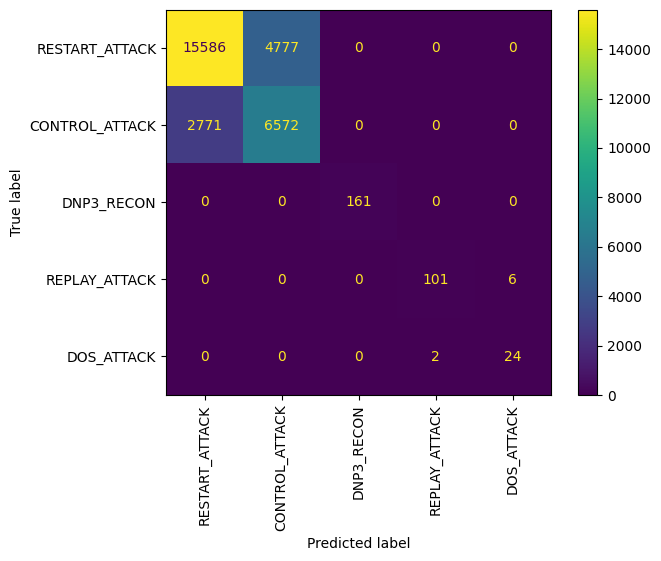

				 EXTRA TREES MODEL
Training ...
CPU times: user 16.3 s, sys: 8.07 ms, total: 16.3 s
Wall time: 16.9 s
training time:  16.91737651824951
 done.
Predicting ...
predicted time:  1.5120248794555664
done


Accuracy: 74.9267%
Precision: 83.8413%
Recall: 84.7476%
F1-Score: 84.209%

Classification Report:
                precision    recall  f1-score   support

RESTART_ATTACK       0.83      0.77      0.80     19778
CONTROL_ATTACK       0.61      0.69      0.65      9928
    DNP3_RECON       1.00      1.00      1.00       161
 REPLAY_ATTACK       0.95      0.94      0.95       104
    DOS_ATTACK       0.80      0.83      0.81        29

      accuracy                           0.75     30000
     macro avg       0.84      0.85      0.84     30000
  weighted avg       0.76      0.75      0.75     30000


Confusion Matrix:


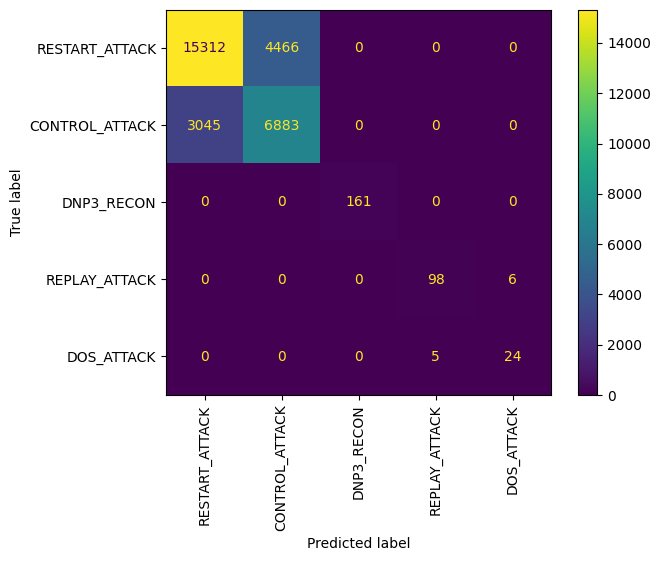

				 LOGISTIC REGRESSION MODEL
Training ...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


CPU times: user 10.9 s, sys: 9.89 ms, total: 10.9 s
Wall time: 6.64 s
training time:  6.644917249679565
 done.
Predicting ...
predicted time:  0.005145072937011719
done


Accuracy: 52.6633%
Precision: 70.7437%
Recall: 31.2045%
F1-Score: 36.8076%

Classification Report:
                precision    recall  f1-score   support

RESTART_ATTACK       0.57      0.66      0.61     15791
CONTROL_ATTACK       0.45      0.40      0.43     12635
    DNP3_RECON       0.99      0.27      0.42       598
 REPLAY_ATTACK       0.83      0.19      0.31       452
    DOS_ATTACK       0.70      0.04      0.08       524

      accuracy                           0.53     30000
     macro avg       0.71      0.31      0.37     30000
  weighted avg       0.53      0.53      0.52     30000


Confusion Matrix:


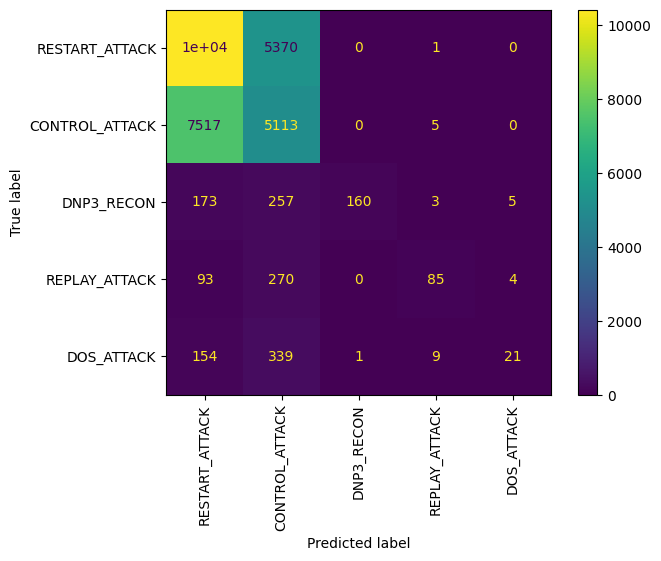

				 NAVIE BAYES MODEL
Training ...
CPU times: user 52.2 ms, sys: 357 µs, total: 52.6 ms
Wall time: 171 ms
training time:  0.1720890998840332
 done.
Predicting ...
predicted time:  0.03910517692565918
done


Accuracy: 61.1133%
Precision: 48.4426%
Recall: 54.7546%
F1-Score: 41.8219%

Classification Report:
                precision    recall  f1-score   support

RESTART_ATTACK       0.90      0.64      0.75     25810
CONTROL_ATTACK       0.15      0.56      0.24      3081
    DNP3_RECON       0.55      0.98      0.71        91
 REPLAY_ATTACK       0.62      0.06      0.12      1006
    DOS_ATTACK       0.20      0.50      0.29        12

      accuracy                           0.61     30000
     macro avg       0.48      0.55      0.42     30000
  weighted avg       0.81      0.61      0.67     30000


Confusion Matrix:


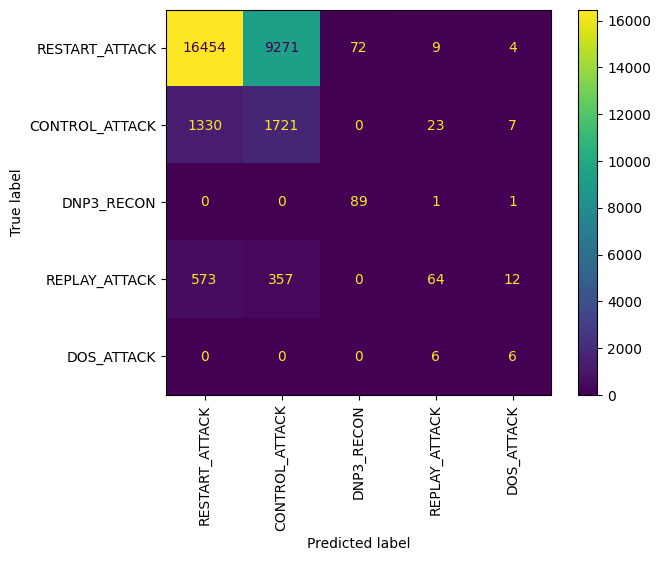

				 LIGHTGBM MODEL
Training ...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.036233 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 722
[LightGBM] [Info] Number of data points in the train set: 120000, number of used features: 10
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
CPU times: user 7.26 s, sys: 29.5 ms, total: 7.29 s
Wall time: 10.4 s
training time:  10.359621524810791
 done.
Predicting ...
predicted time:  0.816525936126709
done


Accuracy: 74.2733%
Precision: 84.8122%
Recall: 84.4827%
F1-Score: 84.5824%

Classificatio

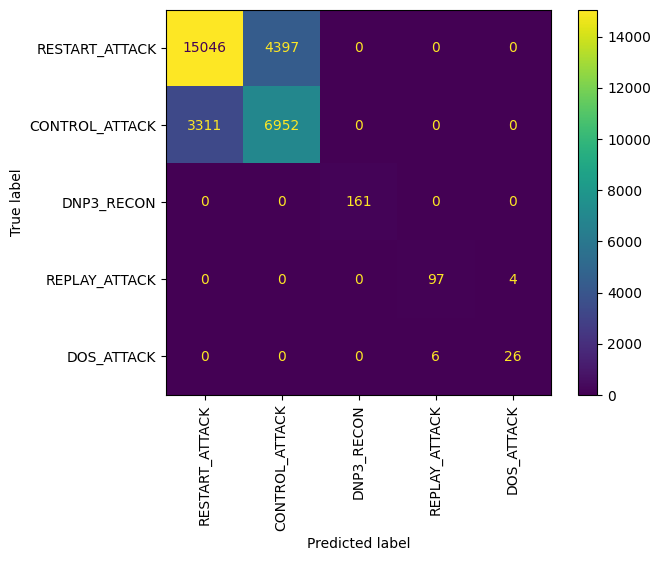

In [ ]:
FINAL_RES_rf = []
for model_name, model_obj in MODELS.items():
  print("="*100)
  print(f"\t\t\t\t {model_name}")
  print("="*100)
  model, rf_time, rf_memory, y_pred1, rf_pred_time = train_model(model_obj, X_train_rf_std, y_train, X_test_rf_std)

  RESULTS = get_results(model, y_pred1.astype(int), y_test, CLASSES, multi_class=True, label_name='RF')
  RESULTS['trainingTime'] = rf_time
  RESULTS['predTime'] = rf_pred_time
  RESULTS['memoryUsage(MB)'] = rf_memory
  results_rf = get_model_results(RESULTS)
  FINAL_RES_rf.append(results_rf)

In [ ]:
df_all_models = pd.concat(FINAL_RES_rf)
models_pd_4 = df_all_models.reset_index()
models_pd_4

,Model,Accuracy,Precision,Recall,F1,trainingTime,predTime,memoryUsage(MB)
0,RandomForestClassifier (RF),74.8133,84.1743,86.7165,85.1866,34.519940,1.079428,490.95465
1,ExtraTreesClassifier (RF),74.9267,83.8413,84.7476,84.2090,16.917377,1.512025,1239.16466
2,LogisticRegression (RF),52.6633,70.7437,31.2045,36.8076,6.644917,0.005145,0.00166
3,GaussianNB (RF),61.1133,48.4426,54.7546,41.8219,0.172089,0.039105,0.00197
4,LGBMClassifier (RF),74.2733,84.8122,84.4827,84.5824,10.359622,0.816526,1.65939


In [ ]:
models_pd_4.to_csv(f"{directory_path}/models_pd_SL.csv", index=False)

In [ ]:
# pd.read_csv(f"{directory_path}/models_pd_SL.csv")

### KAN

In [ ]:
!pip install pykan

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.1/78.1 kB 1.7 MB/s eta 0:00:00


In [ ]:
from kan import KAN
import torch

In [ ]:
def make_dataset_for_KAN(X_train_scaled, X_test_scaled, y_train, y_test):
    """
    Converts scaled training and testing datasets into PyTorch tensors.

    Parameters:
    - X_train_scaled: Scaled training input features (Pandas DataFrame or NumPy array).
    - X_test_scaled: Scaled testing input features (Pandas DataFrame or NumPy array).
    - y_train: Training labels (Pandas Series or DataFrame).
    - y_test: Testing labels (Pandas Series or DataFrame).

    Returns:
    - dataset: A dictionary containing training and testing inputs and labels as PyTorch tensors.
    """
    # Initialize an empty dictionary to hold the dataset
    dataset = {}

    # Convert the training input data from NumPy array to PyTorch tensor and store it in the dataset dictionary
    dataset['train_input'] = torch.from_numpy(X_train_scaled.values).float()

    # Convert the test input data from NumPy array to PyTorch tensor and store it in the dataset dictionary
    dataset['test_input'] = torch.from_numpy(X_test_scaled.values).float()

    # Convert the training labels from a pandas Series or DataFrame to a PyTorch tensor and store it in the dataset dictionary
    dataset['train_label'] = torch.from_numpy(y_train.values)

    # Convert the test labels from a pandas Series or DataFrame to a PyTorch tensor and store it in the dataset dictionary
    dataset['test_label'] = torch.from_numpy(y_test.values)

    return dataset

In [ ]:
def check_in_out_features(X_train_scaled, y_train):
  input_features = X_train_scaled.shape[1]
  output = len(np.unique(y_train))

  return input_features, output

In [ ]:
def fit_KAN_model(model, dataset):
  # Function to calculate training accuracy
  def train_acc():
      # Calculate the mean accuracy for training data
      return torch.mean((torch.argmax(model(dataset['train_input']), dim=1) == dataset['train_label']).float())

  # Function to calculate test accuracy
  def test_acc():
      # Calculate the mean accuracy for test data
      return torch.mean((torch.argmax(model(dataset['test_input']), dim=1) == dataset['test_label']).float())

  # Function to calculate training precision
  def train_precision():
      preds = torch.argmax(model(dataset['train_input']), dim=1)  # Get predictions
      true_positives = torch.sum((preds == 1) & (dataset['train_label'] == 1))  # Count true positives
      predicted_positives = torch.sum(preds == 1)  # Count predicted positives
      return true_positives.float() / predicted_positives.float()  # Calculate precision

  # Function to calculate training recall
  def train_recall():
      preds = torch.argmax(model(dataset['train_input']), dim=1)  # Get predictions
      true_positives = torch.sum((preds == 1) & (dataset['train_label'] == 1))  # Count true positives
      actual_positives = torch.sum(dataset['train_label'] == 1)  # Count actual positives
      return true_positives.float() / actual_positives.float()  # Calculate recall

  # Function to calculate training F1 score
  def train_f1():
      precision = train_precision()  # Get precision
      recall = train_recall()  # Get recall
      return 2 * (precision * recall) / (precision + recall)  # Calculate F1 score

  # Function to calculate test precision
  def test_precision():
      preds = torch.argmax(model(dataset['test_input']), dim=1)  # Get predictions
      true_positives = torch.sum((preds == 1) & (dataset['test_label'] == 1))  # Count true positives
      predicted_positives = torch.sum(preds == 1)  # Count predicted positives
      return true_positives.float() / predicted_positives.float()  # Calculate precision

  # Function to calculate test recall
  def test_recall():
      preds = torch.argmax(model(dataset['test_input']), dim=1)  # Get predictions
      true_positives = torch.sum((preds == 1) & (dataset['test_label'] == 1))  # Count true positives
      actual_positives = torch.sum(dataset['test_label'] == 1)  # Count actual positives
      return true_positives.float() / actual_positives.float()  # Calculate recall

  # Function to calculate test F1 score
  def test_f1():
      precision = test_precision()  # Get precision
      recall = test_recall()  # Get recall
      return 2 * (precision * recall) / (precision + recall)  # Calculate F1 score


  # Function to get memory usage in MB
  def get_memory_usage_mb():
      process = psutil.Process()
      mem_info = process.memory_info()
      return mem_info.rss / (1024 * 1024)  # Convert bytes to MB


  # Measure memory usage before training
  if torch.cuda.is_available():
      mem_before_training = torch.cuda.memory_allocated() / (1024 ** 2)  # Convert bytes to MB
  else:
      mem_before_training = get_memory_usage_mb()

  # Measure training time
  start_time = time.time()


  # train the model
  results = model.fit(
      dataset,
      opt="LBFGS",
      steps=2,
      metrics=(train_acc, test_acc, train_precision, train_recall, train_f1, test_precision, test_recall, test_f1),
      loss_fn=torch.nn.CrossEntropyLoss()
  )


  end_time = time.time()

  # Measure memory usage after training
  if torch.cuda.is_available():
      mem_after_training = torch.cuda.memory_allocated() / (1024 ** 2)  # Convert bytes to MB
  else:
      mem_after_training = get_memory_usage_mb()

  # Calculate time taken for training
  training_time = end_time - start_time

  # Print results
  print(f"\nTraining Time: {training_time} seconds")

  if torch.cuda.is_available():
      print(f"Memory Usage Before Training: {mem_before_training:.2f} MB")
      print(f"Memory Usage After Training: {mem_after_training:.2f} MB")
  else:
      print(f"Memory Usage Before Training: {mem_before_training:.2f} MB")
      print(f"Memory Usage After Training: {mem_after_training:.2f} MB")

  return results, training_time, mem_after_training

In [ ]:
def get_prediction(dataset):
  start_time = time.time()

  # get prediction on testing dataset
  y_pred = torch.argmax(model(dataset['test_input']), dim=1).cpu().detach().numpy()

  end_time = time.time()

  # Calculate time taken for training
  predicting_time = end_time - start_time

  return y_pred, predicting_time

In [ ]:
def performance_metrics(y_pred, dataset, Classes):
  # Classes = ['Normal', 'Attack']

  print("Classification Report:")
  print(classification_report(y_pred, dataset['test_label'].cpu().detach().numpy(),
                              target_names=Classes
                              ))
  print()
  print("Confusion Matrix:")

  fig, ax = plt.subplots(figsize=(7,5))
  ConfusionMatrixDisplay.from_predictions(y_pred, dataset['test_label'].cpu().detach().numpy(),
                                      ax=ax,
                                      display_labels=Classes,
                                      xticks_rotation='vertical')
  plt.show()

In [ ]:
def KAN_evlation(dataset_name='Uni-Flow'):
  dic = {
    'Model':f'KAN ({dataset_name})',
    'Accuracy': round(np.mean(results['test_acc'])*100, 2),
    'Precision': round(np.mean(results['test_precision'])*100, 2),
    'Recall': round(np.mean(results['test_recall'])*100, 2),
    'F1': round(np.mean(results['test_f1'])*100,2),
    'trainingTime': training_time,
    'predTime': predicting_time,
    'memoryUsage(MB)': mem_after_training
}

  # Make a dataframe
  kan_res = pd.DataFrame(dic, index=[0])
  return kan_res

In [ ]:
top_k_features = X_train_rf_std.columns.tolist()
top_k_features

['tcp.time_delta',
 'frame.time_relative',
 'tcp.window_size_value',
 'dnp3.dst_addr',
 'dnp3.src_addr',
 'dnp3.len',
 'frame.len',
 'dnp3.func_code',
 'dnp3.ctrl',
 'tcp.len']

In [ ]:
dataset = make_dataset_for_KAN(X_train_rf_std,
                               X_test_rf_std, y_train, y_test)

In [ ]:
dataset['train_input'].shape, dataset['train_label'].shape

(torch.Size([120000, 10]), torch.Size([120000]))

In [ ]:
input_features,output = check_in_out_features(X_train_rf_std, y_train)
input_features, output

(10, 5)

In [ ]:
import psutil

# KAN is a predefined model class
model = KAN(width=[input_features, output], grid=3, k=3)

checkpoint directory created: ./model
saving model version 0.0


In [ ]:
results, training_time, mem_after_training  = fit_KAN_model(model, dataset)

| train_loss: 8.14e-01 | test_loss: 8.13e-01 | reg: 4.97e+01 | : 100%|█| 2/2 [01:37<00:00, 48.97s/it

saving model version 0.1

Training Time: 97.98555493354797 seconds
Memory Usage Before Training: 6393.20 MB
Memory Usage After Training: 6424.48 MB


Classification Report:
                precision    recall  f1-score   support

RESTART_ATTACK       0.95      0.64      0.77     27187
CONTROL_ATTACK       0.15      0.66      0.25      2640
    DNP3_RECON       0.55      0.99      0.70        89
 REPLAY_ATTACK       0.60      0.83      0.70        75
    DOS_ATTACK       0.17      0.56      0.26         9

      accuracy                           0.65     30000
     macro avg       0.48      0.73      0.53     30000
  weighted avg       0.88      0.65      0.72     30000


Confusion Matrix:


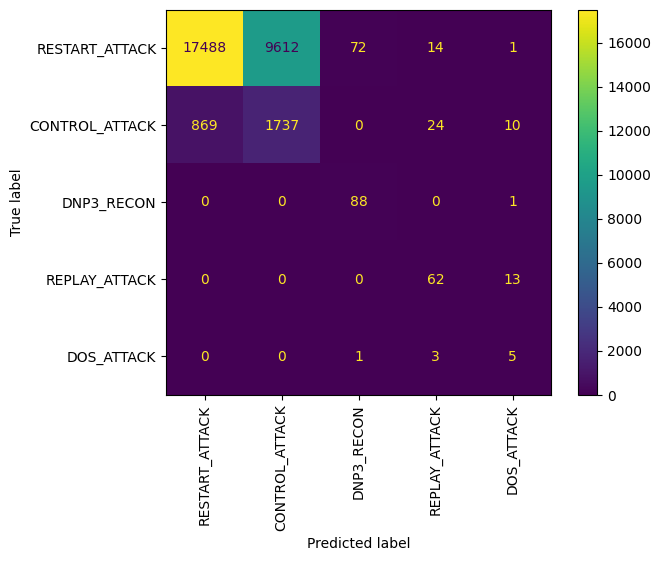

In [ ]:
y_pred, predicting_time = get_prediction(dataset)
performance_metrics(y_pred, dataset, CLASSES)

In [ ]:
kan_res = KAN_evlation(dataset_name='RF')
kan_res

,Model,Accuracy,Precision,Recall,F1,trainingTime,predTime,memoryUsage(MB)
0,KAN (RF),64.41,66.55,13.73,22.71,97.985555,0.186225,6424.476562


In [ ]:
FINAL_RES_RF = pd.concat([models_pd_4, kan_res]).sort_values(by='F1', ascending=False).reset_index(drop=True)
FINAL_RES_RF

,Model,Accuracy,Precision,Recall,F1,trainingTime,predTime,memoryUsage(MB)
0,RandomForestClassifier (RF),74.8133,84.1743,86.7165,85.1866,34.519940,1.079428,490.954650
1,LGBMClassifier (RF),74.2733,84.8122,84.4827,84.5824,10.359622,0.816526,1.659390
2,ExtraTreesClassifier (RF),74.9267,83.8413,84.7476,84.2090,16.917377,1.512025,1239.164660
3,GaussianNB (RF),61.1133,48.4426,54.7546,41.8219,0.172089,0.039105,0.001970
4,LogisticRegression (RF),52.6633,70.7437,31.2045,36.8076,6.644917,0.005145,0.001660
5,KAN (RF),64.4100,66.5500,13.7300,22.7100,97.985555,0.186225,6424.476562


In [ ]:
def model_evaluation_graph(models_pd_):
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np

    sns.set_theme(style="whitegrid", font_scale=1.05)

    perf_metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
    cost_metrics = ['trainingTime', 'predTime', 'memoryUsage(MB)']

    models = models_pd_['Model'].tolist()
    n_models = len(models)
    palette = sns.color_palette("Set2", n_models)

    fig = plt.figure(figsize=(18, 10))
    gs = fig.add_gridspec(2, 3, height_ratios=[1.2, 1])

    # ---- 1. Grouped bar chart: performance metrics ----
    ax1 = fig.add_subplot(gs[0, :])
    x = np.arange(len(perf_metrics))
    width = 0.8 / n_models

    for i, model in enumerate(models):
        values = models_pd_.loc[models_pd_['Model'] == model, perf_metrics].values.flatten()
        bars = ax1.bar(x + i * width, values, width, label=model, color=palette[i], edgecolor='white')
        for bar, val in zip(bars, values):
            ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                      f'{val:.1f}', ha='center', va='bottom', fontsize=8)

    ax1.set_xticks(x + width * (n_models - 1) / 2)
    ax1.set_xticklabels(perf_metrics)
    ax1.set_ylim(0, 105)
    ax1.set_ylabel('Score (%)')
    ax1.set_title('Performance Metrics by Model', fontsize=14, fontweight='bold')
    ax1.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=n_models, frameon=False)
    ax1.spines[['top', 'right']].set_visible(False)

    # ---- 2-4. Cost metrics: training time, prediction time, memory ----
    cost_titles = ['Training Time (s)', 'Prediction Time (s)', 'Memory Usage (MB)']
    tick_pos = np.arange(n_models)

    for idx, (metric, title) in enumerate(zip(cost_metrics, cost_titles)):
        ax = fig.add_subplot(gs[1, idx])
        values = models_pd_[metric].values
        bars = ax.bar(tick_pos, values, color=palette, edgecolor='white')
        for bar, val in zip(bars, values):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                     f'{val:.2f}', ha='center', va='bottom', fontsize=8)
        ax.set_xticks(tick_pos)
        ax.set_xticklabels(models, rotation=30, ha='right', fontsize=8)
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.spines[['top', 'right']].set_visible(False)

    fig.suptitle('Model Performance & Efficiency Comparison', fontsize=18, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    # ---- 5. Heatmap: quick scan of all metrics together ----
    all_metrics = perf_metrics + cost_metrics
    heat_df = models_pd_.set_index('Model')[all_metrics]
    heat_norm = (heat_df - heat_df.min()) / (heat_df.max() - heat_df.min())

    plt.figure(figsize=(10, 0.6 * n_models + 2))
    sns.heatmap(heat_norm, annot=heat_df.round(2), fmt='', cmap='YlGnBu',
                cbar_kws={'label': 'Normalized Score'}, linewidths=0.5)
    plt.title('Metric Heatmap (normalized, raw values annotated)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

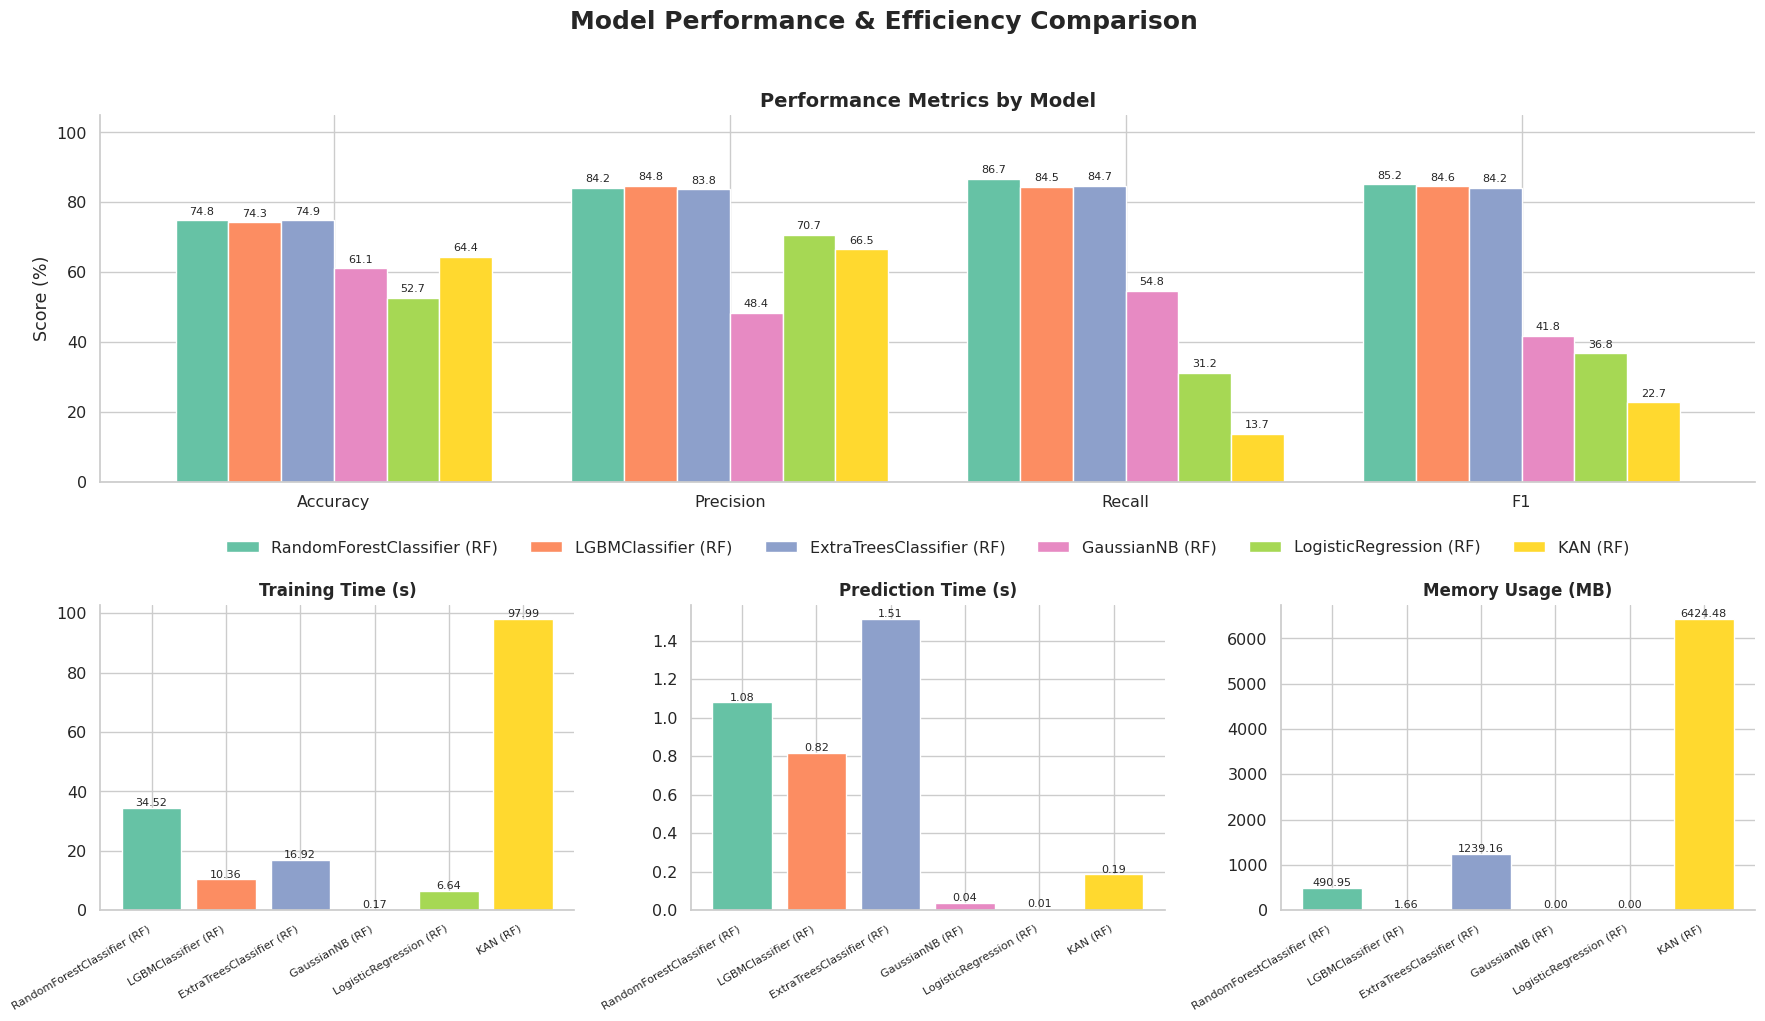

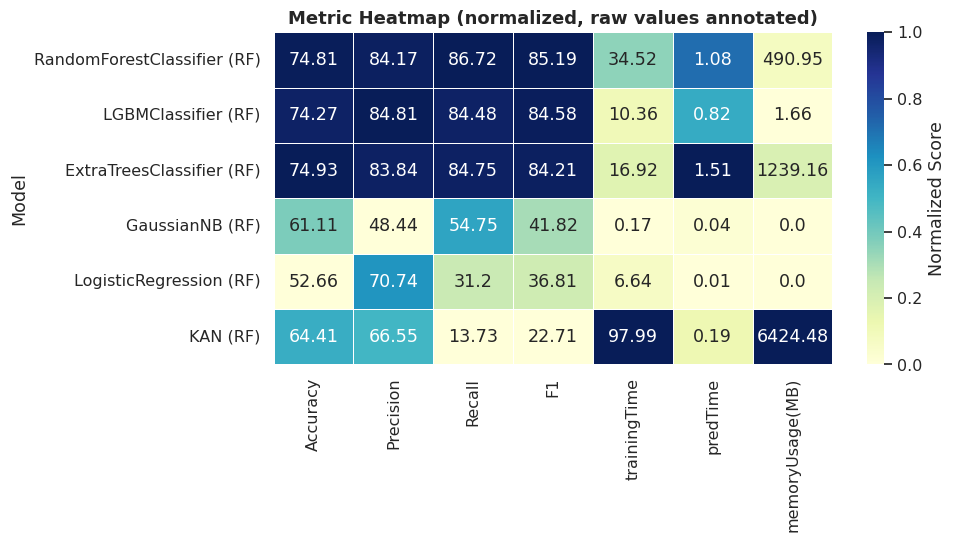

In [ ]:
model_evaluation_graph(FINAL_RES_RF)

#### Concatenating

In [ ]:
X_train_rf_std.shape, X_train_rf_std.columns

((120000, 10),
 Index(['tcp.time_delta', 'frame.time_relative', 'tcp.window_size_value',
        'dnp3.dst_addr', 'dnp3.src_addr', 'dnp3.len', 'frame.len',
        'dnp3.func_code', 'dnp3.ctrl', 'tcp.len'],
       dtype='object'))

In [ ]:
top_k_features = X_train_rf_std.columns.tolist()

In [ ]:
df_train_rf = pd.DataFrame(X_train_rf_std, columns=top_k_features)
df_test_rf = pd.DataFrame(X_test_rf_std, columns=top_k_features)

In [ ]:
fullData = pd.concat([df_train_rf, df_test_rf])
fullLabel = pd.concat([y_train, y_test]).values

fullData.shape, fullLabel.shape

((150000, 10), (150000,))

In [ ]:
fullData.head()

,tcp.time_delta,frame.time_relative,tcp.window_size_value,dnp3.dst_addr,dnp3.src_addr,dnp3.len,frame.len,dnp3.func_code,dnp3.ctrl,tcp.len
0,-0.090972,1.535215,-0.919550,-0.931481,1.566662,-0.189701,-0.155909,1.014836,-0.985418,-0.155903
1,-0.090974,0.081646,1.205609,0.755289,-0.965073,-0.160965,-0.140360,-0.995816,1.014355,-0.140354
2,-0.090952,-0.735798,1.205609,1.261320,-0.965073,-0.160965,-0.140360,-0.995816,1.014355,-0.140354
3,-0.090961,-0.058881,1.205609,0.417935,-0.965073,-0.160965,-0.140360,-0.995816,1.014355,-0.140354
4,-0.090820,0.234998,-0.919550,-1.100159,1.060315,-0.189701,-0.155909,1.014836,-0.985418,-0.155903


In [ ]:
fullLabel[:4]

array([0, 0, 0, 0])

### Saving And Loading Model

In [ ]:
import pickle
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report

# === Train Model ===
best_model = RandomForestClassifier(class_weight='balanced')
best_model.fit(fullData, fullLabel)
# best_model.fit(X_train_rf_std, y_train)

# === Predictions ===
# y_pred = best_model.predict(fullData)
# y_pred = best_model.predict(X_test_rf_std)
# print(classification_report(fullLabel, y_pred))
# print(classification_report(y_test, y_pred))


# === Save Model ===
with open(f"{directory_path}/DNP3_RF_best_model.pkl", "wb") as f:
    pickle.dump(best_model, f)


print("✅ Model saved as best_model.pkl")

✅ Model saved as best_model.pkl


In [ ]:
import pickle
# === Load Model ===
with open(f"{directory_path}/DNP3_RF_best_model.pkl", "rb") as f:
    loaded_model = pickle.load(f)

In [ ]:
with open(f"{directory_path}/dnp3_scaler_for_SL.pkl", "rb") as f:
    loaded_scaler = pickle.load(f)

In [ ]:
import pickle
import os
import sys

# === Load Model ===
model_path = f"{directory_path}/DNP3_RF_best_model.pkl"

# File size on disk
file_size_bytes = os.path.getsize(model_path)
file_size_mb = file_size_bytes / (1024 * 1024)
print(f"📦 File size on disk: {file_size_mb:.2f} MB")

# Load model
with open(model_path, "rb") as f:
    loaded_model = pickle.load(f)

# Memory size (in-RAM)
ram_size_bytes = sys.getsizeof(pickle.dumps(loaded_model))
ram_size_mb = ram_size_bytes / (1024 * 1024)
print(f"🧠 Model size in RAM: {ram_size_mb:.2f} MB")

# Extra info
print(f"\n🌳 n_estimators : {loaded_model.n_estimators}")
print(f"📊 n_features   : {loaded_model.n_features_in_}")
print(f"🏷️  n_classes    : {loaded_model.n_classes_}")

📦 File size on disk: 605.53 MB
🧠 Model size in RAM: 605.53 MB

🌳 n_estimators : 100
📊 n_features   : 10
🏷️  n_classes    : 5


### Get Prediction

In [ ]:
fullData.columns

Index(['tcp.time_delta', 'frame.time_relative', 'tcp.window_size_value',
       'dnp3.dst_addr', 'dnp3.src_addr', 'dnp3.len', 'frame.len',
       'dnp3.func_code', 'dnp3.ctrl', 'tcp.len'],
      dtype='object')

In [ ]:
top_k_features

['tcp.time_delta',
 'frame.time_relative',
 'tcp.window_size_value',
 'dnp3.dst_addr',
 'dnp3.src_addr',
 'dnp3.len',
 'frame.len',
 'dnp3.func_code',
 'dnp3.ctrl',
 'tcp.len']

In [ ]:
Training_features = ['tcp.time_delta',
 'frame.time_relative',
 'tcp.window_size_value',
 'dnp3.dst_addr',
 'dnp3.src_addr',
 'dnp3.len',
 'frame.len',
 'dnp3.func_code',
 'dnp3.ctrl',
 'tcp.len']

In [ ]:
fullData.columns

Index(['tcp.time_delta', 'frame.time_relative', 'tcp.window_size_value',
       'dnp3.dst_addr', 'dnp3.src_addr', 'dnp3.len', 'frame.len',
       'dnp3.func_code', 'dnp3.ctrl', 'tcp.len'],
      dtype='object')

In [ ]:
fullData.head()

,tcp.time_delta,frame.time_relative,tcp.window_size_value,dnp3.dst_addr,dnp3.src_addr,dnp3.len,frame.len,dnp3.func_code,dnp3.ctrl,tcp.len
0,-0.090972,1.535215,-0.919550,-0.931481,1.566662,-0.189701,-0.155909,1.014836,-0.985418,-0.155903
1,-0.090974,0.081646,1.205609,0.755289,-0.965073,-0.160965,-0.140360,-0.995816,1.014355,-0.140354
2,-0.090952,-0.735798,1.205609,1.261320,-0.965073,-0.160965,-0.140360,-0.995816,1.014355,-0.140354
3,-0.090961,-0.058881,1.205609,0.417935,-0.965073,-0.160965,-0.140360,-0.995816,1.014355,-0.140354
4,-0.090820,0.234998,-0.919550,-1.100159,1.060315,-0.189701,-0.155909,1.014836,-0.985418,-0.155903


In [ ]:
INPUT = X.iloc[0].to_dict()
INPUT = pd.DataFrame([INPUT])
INPUT

,frame.time_relative,frame.len,frame.cap_len,tcp.srcport,tcp.dstport,tcp.len,tcp.window_size_value,tcp.time_delta,dnp3.len,dnp3.ctrl,dnp3.dst_addr,dnp3.src_addr,dnp3.dir,dnp3.prm,dnp3.func_code_link,dnp3.func_code,dnp3.payload_len
0,0.000756,83.0,83.0,20001.0,41538.0,17.0,227.0,0.000756,10.0,68.0,2.0,13.0,0.0,1.0,4.0,129.0,17.0


In [ ]:
X.columns.tolist()

['frame.time_relative',
 'frame.len',
 'frame.cap_len',
 'tcp.srcport',
 'tcp.dstport',
 'tcp.len',
 'tcp.window_size_value',
 'tcp.time_delta',
 'dnp3.len',
 'dnp3.ctrl',
 'dnp3.dst_addr',
 'dnp3.src_addr',
 'dnp3.dir',
 'dnp3.prm',
 'dnp3.func_code_link',
 'dnp3.func_code',
 'dnp3.payload_len']

In [ ]:
# Define class labels in the same order as training
CLASSES = ["RESTART_ATTACK", "CONTROL_ATTACK", "DNP3_RECON", "REPLAY_ATTACK", "DOS_ATTACK"]

def get_prediction(input_data, loaded_model, loaded_scaler, training_features):
    """
    input_data: array-like (1D list/NumPy array for a single sample)
    loaded_model: previously loaded ML model
    loaded_scaler: previously loaded scaler
    training_features: ordered list of feature names used during training
    """
    # Scale the input
    input_scaled = loaded_scaler.transform(input_data)
    print(input_scaled)

    # Create DataFrame with proper columns
    INPUT_std_df = pd.DataFrame(
        input_scaled,
        columns=['frame.time_relative',
 'frame.len',
 'frame.cap_len',
 'tcp.srcport',
 'tcp.dstport',
 'tcp.len',
 'tcp.window_size_value',
 'tcp.time_delta',
 'dnp3.len',
 'dnp3.ctrl',
 'dnp3.dst_addr',
 'dnp3.src_addr',
 'dnp3.dir',
 'dnp3.prm',
 'dnp3.func_code_link',
 'dnp3.func_code',
 'dnp3.payload_len']
    )[training_features]

    # Predict probabilities
    y_proba = loaded_model.predict_proba(INPUT_std_df)[0]

    # Convert to Python floats
    y_proba = y_proba.astype(float)

    # Predicted class index
    y_pred_idx = y_proba.argmax()

    # Map index to class name
    predicted_label = CLASSES[y_pred_idx]
    predicted_prob = float(y_proba[y_pred_idx])

    return {
        "predicted_label": predicted_label,
        "probability": round(predicted_prob, 4)*100,
        "all_probabilities": {cls: round(float(p), 4)*100 for cls, p in zip(CLASSES, y_proba)}
    }


In [ ]:
get_prediction(INPUT, loaded_model, loaded_scaler, Training_features)

[[-1.73283054e+00 -1.55909429e-01 -1.55909429e-01 -9.06726477e-01
   5.59295174e-01 -1.55903490e-01 -9.19549886e-01 -9.07508709e-02
  -1.89701229e-01 -9.85418188e-01 -1.10015851e+00  7.22750424e-01
  -9.85428327e-01  9.99382073e-04 -5.17851459e-02  1.01483649e+00
  -1.55903490e-01]]


{'predicted_label': 'RESTART_ATTACK',
 'probability': 53.0,
 'all_probabilities': {'RESTART_ATTACK': 53.0,
  'CONTROL_ATTACK': 47.0,
  'DNP3_RECON': 0.0,
  'REPLAY_ATTACK': 0.0,
  'DOS_ATTACK': 0.0}}